In [1]:
pip install mplsoccer statsbombpy


   ---------------------------------------- 0/6 [url-normalize]
   ------ --------------------------------- 1/6 [typeguard]
   ------------- -------------------------- 2/6 [requests-cache]
   -------------------- ------------------- 3/6 [inflect]
   --------------------------------- ------ 5/6 [mplsoccer]
   --------------------------------- ------ 5/6 [mplsoccer]
   --------------------------------- ------ 5/6 [mplsoccer]
   ---------------------------------------- 6/6 [mplsoccer]

Note: you may need to restart the kernel to use updated packages.


In [1]:
# importing packages
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from statsbombpy import sb
print("all good")

all good


In [2]:
# ── 1. Get all Euro 2024 matches (competition_id=55, season_id=282) ──
matches = sb.matches(competition_id=55, season_id=282)

# Filter to France games only
france_matches = matches[
    (matches['home_team'] == 'France') | (matches['away_team'] == 'France')
]
display(france_matches)
print(france_matches.columns.tolist())

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
7,3938643,2024-06-25,16:00:00.000,1,1,available,available,2026-05-01T09:32:36.453598,2026-05-01T09:37:02.207863,3,...,France,363,Michał Probierz,None,1972-09-24,182,Poland,1.1.0,2,2
15,3941019,2024-07-01,16:00:00.000,1,0,available,available,2026-04-28T18:43:38.448635,2026-04-28T18:46:34.258160,4,...,France,48,Domenico Tedesco,None,1985-09-12,85,Germany,1.1.0,2,2
23,3942752,2024-07-09,19:00:00.000,2,1,available,available,2026-04-29T01:43:46.587696,2026-04-29T01:46:24.320801,6,...,Spain,545,Didier Deschamps,None,1968-10-15,78,France,1.1.0,2,2
25,3942349,2024-07-05,19:00:00.000,0,0,available,available,2026-04-29T01:41:50.982383,2026-04-29T01:43:49.615367,5,...,Spain,545,Didier Deschamps,None,1968-10-15,78,France,1.1.0,2,2
41,3930173,2024-06-21,19:00:00.000,0,0,available,available,2026-05-01T19:51:17.821277,2026-05-01T19:55:53.005892,2,...,Netherlands,545,Didier Deschamps,None,1968-10-15,78,France,1.1.0,2,2
45,3930165,2024-06-17,19:00:00.000,0,1,available,available,2026-05-01T19:50:29.633847,2026-05-01T19:54:15.076346,1,...,Germany,545,Didier Deschamps,None,1968-10-15,78,France,1.1.0,2,2


['match_id', 'match_date', 'kick_off', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'match_week', 'competition_id', 'competition_country_name', 'competition_name', 'competition', 'season_id', 'season', 'home_team_id', 'home_team', 'home_team_gender', 'home_team_group', 'home_team_country_id', 'home_team_country_name', 'away_team_id', 'away_team', 'away_team_gender', 'away_team_group', 'away_team_country_id', 'away_team_country_name', 'competition_stage_id', 'competition_stage', 'stadium_id', 'stadium', 'stadium_country_id', 'stadium_country_name', 'referee_id', 'referee', 'referee_country_id', 'referee_country_name', 'home_managers', 'away_managers', 'home_manager_id', 'home_manager_name', 'home_manager_nickname', 'home_manager_dob', 'home_manager_country_id', 'home_manager_country_name', 'away_manager_id', 'away_manager_name', 'away_manager_nickname', 'away_manager_dob', 'away_manager_country_id', 'away_manager_country_name', 'dat

In [3]:
# ── 2. Load all events from France's matches ──
all_events = []
for match_id in france_matches['match_id']:
    events = sb.events(match_id=match_id)
    all_events.append(events)

df = pd.concat(all_events, ignore_index=True)

In [4]:
# ── 3. Filter for Tchouaméni ──
tchouameni = df[df['player'].str.contains('Tchou', case=False, na=False)]

# Extract x/y locations (StatsBomb stores as [x, y] lists)
tchouameni = tchouameni.dropna(subset=['location'])
tchouameni['x'] = tchouameni['location'].apply(lambda loc: loc[0])
tchouameni['y'] = tchouameni['location'].apply(lambda loc: loc[1])

print(f"Total actions for Tchouaméni: {len(tchouameni)}")
print(tchouameni['type'].value_counts().head(10))

Total actions for Tchouaméni: 1200
type
Pass              381
Ball Receipt*     359
Carry             328
Pressure           60
Shot               12
Ball Recovery      10
Duel               10
Foul Committed      8
Clearance           8
Foul Won            6
Name: count, dtype: int64


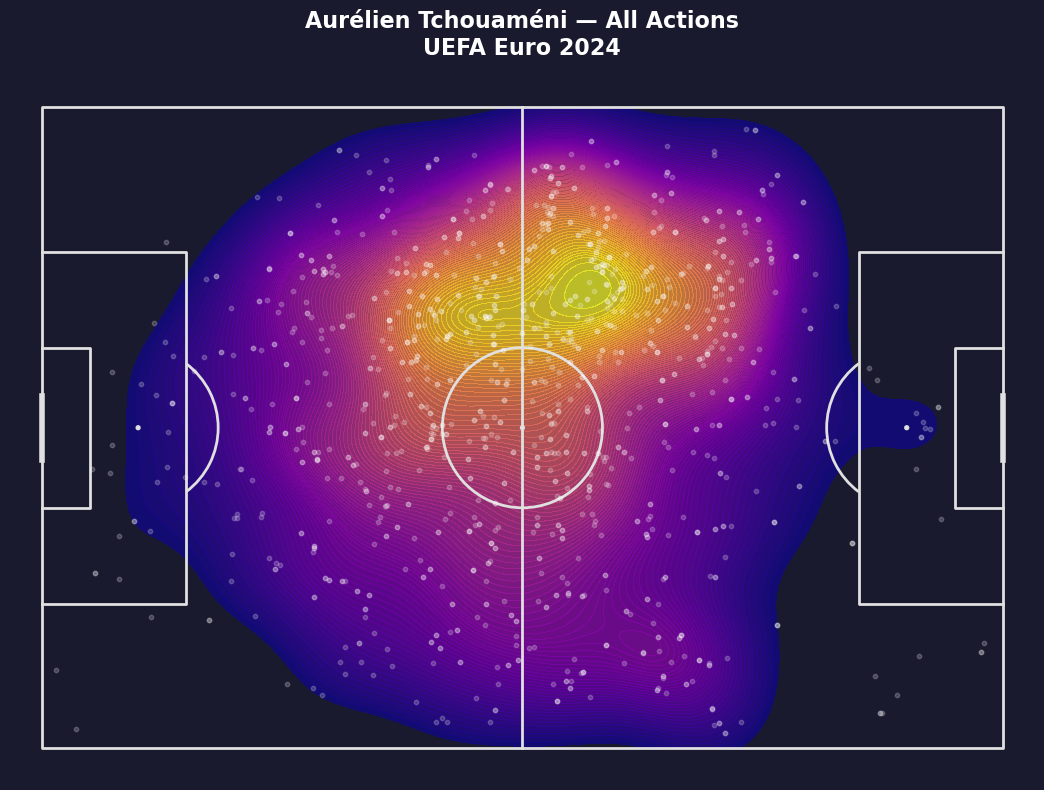

In [6]:
# ── 4. Draw the heatmap ──
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#1a1a2e',
    line_color='#e0e0e0',
    line_zorder=2
)

fig, ax = pitch.draw(figsize=(12, 8))
fig.set_facecolor('#1a1a2e')

# Kernel density heatmap
pitch.kdeplot(
    tchouameni['x'],
    tchouameni['y'],
    ax=ax,
    cmap='plasma',
    fill=True,
    levels=100,
    alpha=0.75,
    zorder=1
)

# Optional: scatter dots for each action
pitch.scatter(
    tchouameni['x'],
    tchouameni['y'],
    ax=ax,
    s=10,
    color='white',
    alpha=0.2,
    zorder=3
)

ax.set_title(
    "Aurélien Tchouaméni — All Actions\nUEFA Euro 2024",
    color='white',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.savefig("C:/Users/LENOVO/Downloads/tchouameni_heatmap_euro2024.jpg", dpi=150, bbox_inches='tight')
plt.show()